In [1]:
# Airbnb Price Prediction

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [2]:
# Load and Clean Data
df = pd.read_csv(r"C:\Users\GOWTHAM\Downloads\Dataset.csv")

# Fill missing values
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Remove duplicates and unrealistic values
df.drop_duplicates(inplace=True)
df = df[(df['price'] > 0) & (df['price'] < 1000)]
df = df[df['minimum_nights'] <= 365]
df.reset_index(drop=True, inplace=True)

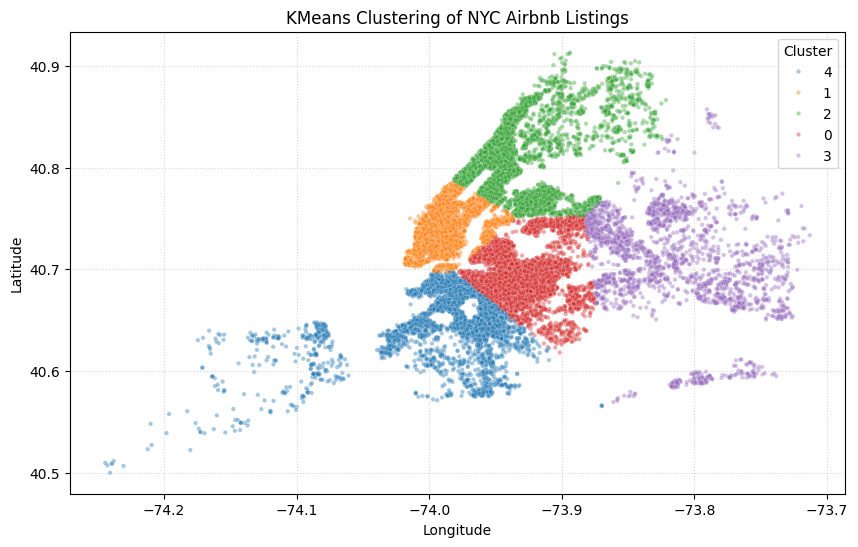

In [3]:
# Feature Engineering
df['log_price'] = np.log1p(df['price'])
df['log_minimum_nights'] = np.log1p(df['minimum_nights'])
df['reviews_activity'] = df['reviews_per_month'] * df['number_of_reviews']
df['host_ratio'] = df['calculated_host_listings_count'] / (df['availability_365'] + 1)

# Location clustering
coords = df[['latitude', 'longitude']]
df['location_cluster'] = KMeans(n_clusters=5, random_state=42).fit_predict(coords)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['longitude'],
    y=df['latitude'],
    hue=df['location_cluster'].astype(str),
    palette='tab10',
    alpha=0.4,
    s=10
)

plt.title("KMeans Clustering of NYC Airbnb Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# One-hot encoding
categorical_features = ['neighbourhood_group', 'room_type', 'location_cluster']
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded = pd.DataFrame(ohe.fit_transform(df[categorical_features]),
                       columns=ohe.get_feature_names_out(categorical_features))
df = pd.concat([df, encoded], axis=1)
df.drop(columns=categorical_features, inplace=True)

# Scale numerical features
num_features = ['log_minimum_nights', 'number_of_reviews', 'reviews_per_month',
                'availability_365', 'calculated_host_listings_count',
                'reviews_activity', 'host_ratio']
df[num_features] = StandardScaler().fit_transform(df[num_features])

In [4]:
# Prepare features and split
X = df.drop(columns=['price', 'log_price', 'id', 'name', 'host_id', 'host_name', 'last_review', 'neighbourhood']) 
y = df['log_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Model Training & Hyperparameter Tuning

# 1) Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# 2) Random Forest with RandomizedSearchCV
rf = RandomForestRegressor(random_state=42)
rf_params = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_search = RandomizedSearchCV(rf, rf_params, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("RandomForest best params:", rf_search.best_params_)

# 3) Gradient Boosting with RandomizedSearchCV
gbr = GradientBoostingRegressor(random_state=42)
gbr_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 8]
}
gbr_search = RandomizedSearchCV(gbr, gbr_params, n_iter=6, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
gbr_search.fit(X_train, y_train)
best_gbr = gbr_search.best_estimator_
print("GradientBoosting best params:", gbr_search.best_params_)

RandomForest best params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 20}
GradientBoosting best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}


In [6]:
# Evaluate All Models
def evaluate_predictions(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2

models = {'LinearRegression': lr, 'RandomForest': best_rf, 'GradientBoosting': best_gbr}
results = []

for name, model in models.items():
    preds = model.predict(X_test)
    mse, rmse, r2 = evaluate_predictions(y_test, preds)
    results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'R2_Score': r2})

results_df = pd.DataFrame(results).sort_values(by='RMSE')
print("\nModel Evaluation Results:")
print(results_df)


Model Evaluation Results:
              Model       MSE      RMSE  R2_Score
1      RandomForest  0.150981  0.388563  0.646456
2  GradientBoosting  0.157993  0.397484  0.630036
0  LinearRegression  0.185833  0.431083  0.564847


C:\Users\GOWTHAM\AppData\Local\Temp\ipykernel_16924\736395662.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


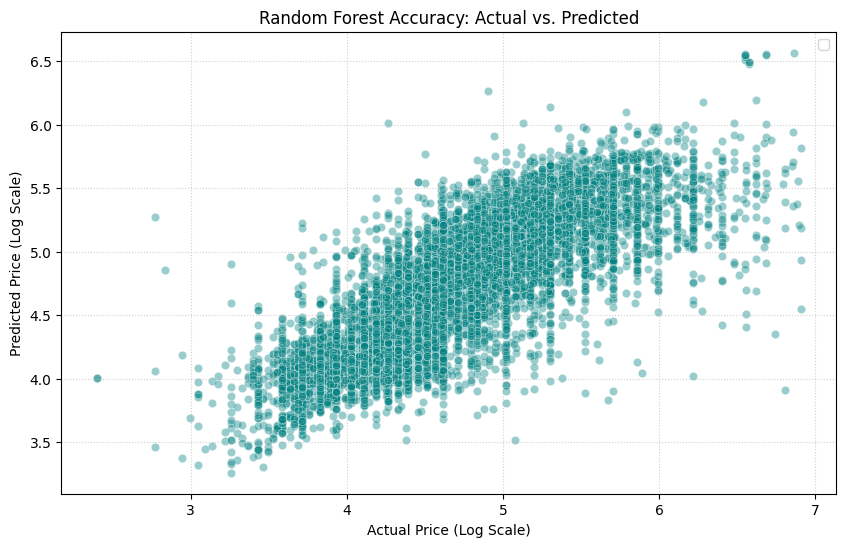

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from the Random Forest model
rf_preds = best_rf.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=rf_preds, alpha=0.4, color='teal')

# Formatting
plt.xlabel('Actual Price (Log Scale)')
plt.ylabel('Predicted Price (Log Scale)')
plt.title('Random Forest Accuracy: Actual vs. Predicted')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [8]:
importances = best_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nTop Features Driving Airbnb Prices:")
print(feature_importance_df.head(10))


Top Features Driving Airbnb Prices:
                   Feature  Importance
14  room_type_Private room    0.396362
16      location_cluster_1    0.106622
1                longitude    0.096114
0                 latitude    0.090072
15   room_type_Shared room    0.084329
6         availability_365    0.045141
9               host_ratio    0.036696
8         reviews_activity    0.029958
4        reviews_per_month    0.028411
3        number_of_reviews    0.023997


In [9]:
# --- Step 7: Save Best Model ---
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
joblib.dump(best_model, 'best_airbnb_model.pkl')
print(f"Best model '{best_model_name}' saved as best_airbnb_model.pkl")

Best model 'RandomForest' saved as best_airbnb_model.pkl


In [10]:
import joblib

model = joblib.load("best_airbnb_model.pkl")

In [11]:
X.head()

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_minimum_nights,reviews_activity,host_ratio,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room,location_cluster_1,location_cluster_2,location_cluster_3,location_cluster_4
0,40.64749,-73.97237,1,-0.321971,-0.553488,-0.035411,1.923742,-0.932149,-0.280698,-0.208106,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,40.75362,-73.98377,1,0.484187,-0.447239,-0.156438,1.847611,-0.932149,-0.215815,-0.211991,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,40.80902,-73.94190,3,-0.523510,-0.684737,-0.186695,1.923742,-0.128715,-0.288760,-0.213032,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,40.68514,-73.95976,1,5.522670,2.215247,-0.186695,0.621887,-0.932149,5.055438,-0.212168,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,40.79851,-73.94399,10,-0.321971,-0.622238,-0.186695,-0.855071,1.043842,-0.284921,0.146590,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [14]:
# Load model
model = joblib.load("best_airbnb_model.pkl")

# Example input
sample = pd.DataFrame([[40.64749, -73.97237, 1, -0.321971, -0.553488, -0.035411, 1.923742, -0.932149, -0.280698, -0.208106, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0]],
                    columns = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'log_minimum_nights', 'reviews_activity', 'host_ratio', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Private room', 'room_type_Shared room', 'location_cluster_1', 'location_cluster_2', 'location_cluster_3', 'location_cluster_4'])  # your features

# Predict
prediction = model.predict(sample)
print(prediction)

[4.36483279]
